In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from sklearn import set_config

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.model_selection import train_test_split
set_config(display="text")  # displays text representation of estimators

from sksurv.util import Surv
sys.path.append(os.path.abspath("../../"))
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.Preprocessing import Preprocessor
from lifelines import CoxPHFitter
from src.utils.cox_models import Cox_regression, p_values_Cox_regression, plot_coefficients
%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
pp = Preprocessor()
cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_keep = pp.clean_columns_dataset(df_clinical_data)


<font size="4">Preprocessing</font>

In [52]:
list_df = pp.total_type_len_type_cancer(df_clinical_keep)
df_clinical_keep["Tumor-Cancer"] = list_df
df_mRNA_transformed = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
clean_df = pp.elimnation_zeros(df_mRNA_transformed, "Hugo_Symbol")

Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)
Max of zeros per row in the dataset: 4575
Avg of zeros per row in the dataset: 2911.273838630807
Median of zeros per row in the dataset: 2866.5
Min of zeros per row in the dataset: 0
After the 0 elimination: 454


<font size="4">ESR1 coefficients and p_values</font>

In [53]:
df_ESR1 = pp.gene_to_long(clean_df,"ESR1")

In [54]:
df_ESR1_merged = df_ESR1.merge(df_clinical_keep, on="Sample ID", how="inner")
status = df_ESR1_merged["Overall Survival Status"].astype(str).str.strip()
df_ESR1_merged["event"] = status.str.contains("DECEASED", na=False) 
df_ESR1_merged = df_ESR1_merged.dropna(subset=["Overall Survival (Months)"])
X_ESR1 = df_ESR1_merged[["expression"]]
Y_surv_ESR1 = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=df_ESR1_merged
)

In [55]:
X_train_ESR1, X_test_ESR1, Y_train_ESR1, Y_test_ESR1 = train_test_split(
    X_ESR1, Y_surv_ESR1, train_size=0.80, test_size=0.20, random_state=42
)


In [56]:
betas_ESR1, chp_predict_ESR1, survival_curve_ESR1, risk_curve_ESR1 = Cox_regression(X_train_ESR1, Y_train_ESR1, X_test_ESR1)

In [57]:
print(betas_ESR1)
#Alpha is regularization 
#Low alpha == Low regularization
#Big alpha == Big regularization

#Espression == Betas 
#β > 0 → aumenta el riesgo
#β < 0 → reduce el riesgo
#β ≈ 0 → no hay efecto

alpha       0.00010      0.00015      0.00021      0.00031      0.00045      \
expression    -0.000004    -0.000004    -0.000004    -0.000004    -0.000004   

alpha       0.00066      0.00095      0.00139      0.00202      0.00295      \
expression    -0.000004    -0.000004    -0.000004    -0.000004    -0.000004   

alpha       ...  339.32218    494.17134    719.68567    1048.11313   \
expression  ...    -0.000004    -0.000004    -0.000004    -0.000004   

alpha       1526.41797   2222.99648   3237.45754   4714.86636   6866.48845   \
expression    -0.000004    -0.000004    -0.000004    -0.000004    -0.000004   

alpha       10000.00000  
expression    -0.000004  

[1 rows x 50 columns]


In [58]:
print(chp_predict_ESR1)

# Risk Score = Expression x β
# valor más alto → mayor riesgo relativo
#valor más bajo → menor riesgo relativo

[-1.11913345e-01 -8.29724822e-02 -2.55550245e-02 -2.59254334e-02
 -9.08697688e-02 -1.07524525e-01 -2.68978647e-02 -9.92847531e-02
 -5.73786409e-02 -4.32493769e-02 -4.92485410e-02 -4.80035186e-02
 -5.65868129e-02 -9.73298147e-04 -4.52104017e-03 -6.41825361e-02
 -1.76414387e-02 -4.78584334e-02 -3.23083008e-01 -5.06360425e-02
 -5.08319931e-04 -1.12844306e-02 -3.23505188e-03 -1.13626371e-01
 -2.03960278e-04 -1.13316913e-03 -4.56748358e-02 -1.00659733e-02
 -6.71147772e-02 -1.45152479e-01 -1.71665141e-01 -5.89058108e-02
 -2.43573192e-03 -1.13015713e-01 -2.84549337e-02 -8.89708787e-02
 -2.72502609e-02 -1.16782328e-01 -2.39971649e-02 -3.33182253e-02
 -4.22355906e-02 -2.86613178e-02 -3.91710175e-02 -1.08994400e-01
 -7.89093770e-02 -4.30719059e-04 -1.04015682e-01 -2.22601528e-02
 -3.92305501e-03 -4.20723103e-02 -3.77170724e-04 -2.11507789e-04
 -2.32093594e-02 -1.74655166e-01 -3.49872677e-02 -1.27388001e-02
 -5.79033924e-04 -1.81271582e-02 -4.51013527e-03 -6.22043509e-02
 -2.67296754e-02 -4.36008

In [59]:
print(survival_curve_ESR1)

[StepFunction(x=array([0.0000e+00, 3.0000e-02, 1.6000e-01, 3.3000e-01, 3.6000e-01,
        6.9000e-01, 9.9000e-01, 1.0200e+00, 1.1200e+00, 1.6100e+00,
        2.7600e+00, 3.2200e+00, 5.5800e+00, 5.6500e+00, 6.1100e+00,
        6.5700e+00, 6.9000e+00, 7.1600e+00, 7.2900e+00, 7.3900e+00,
        7.8500e+00, 7.9500e+00, 8.4800e+00, 8.9700e+00, 9.7600e+00,
        9.9900e+00, 1.0090e+01, 1.0280e+01, 1.0510e+01, 1.0580e+01,
        1.0780e+01, 1.1040e+01, 1.1070e+01, 1.1270e+01, 1.1330e+01,
        1.1500e+01, 1.1830e+01, 1.1890e+01, 1.1960e+01, 1.1990e+01,
        1.2020e+01, 1.2190e+01, 1.2250e+01, 1.2320e+01, 1.2480e+01,
        1.2520e+01, 1.2580e+01, 1.2650e+01, 1.2910e+01, 1.2940e+01,
        1.3010e+01, 1.3040e+01, 1.3070e+01, 1.3240e+01, 1.3440e+01,
        1.3470e+01, 1.3600e+01, 1.3670e+01, 1.3900e+01, 1.3930e+01,
        1.3990e+01, 1.4060e+01, 1.4290e+01, 1.4420e+01, 1.4450e+01,
        1.4490e+01, 1.4680e+01, 1.4780e+01, 1.4820e+01, 1.4910e+01,
        1.5470e+01, 1.5510e+01, 1

In [60]:
print(risk_curve_ESR1)

[StepFunction(x=array([0.0000e+00, 3.0000e-02, 1.6000e-01, 3.3000e-01, 3.6000e-01,
        6.9000e-01, 9.9000e-01, 1.0200e+00, 1.1200e+00, 1.6100e+00,
        2.7600e+00, 3.2200e+00, 5.5800e+00, 5.6500e+00, 6.1100e+00,
        6.5700e+00, 6.9000e+00, 7.1600e+00, 7.2900e+00, 7.3900e+00,
        7.8500e+00, 7.9500e+00, 8.4800e+00, 8.9700e+00, 9.7600e+00,
        9.9900e+00, 1.0090e+01, 1.0280e+01, 1.0510e+01, 1.0580e+01,
        1.0780e+01, 1.1040e+01, 1.1070e+01, 1.1270e+01, 1.1330e+01,
        1.1500e+01, 1.1830e+01, 1.1890e+01, 1.1960e+01, 1.1990e+01,
        1.2020e+01, 1.2190e+01, 1.2250e+01, 1.2320e+01, 1.2480e+01,
        1.2520e+01, 1.2580e+01, 1.2650e+01, 1.2910e+01, 1.2940e+01,
        1.3010e+01, 1.3040e+01, 1.3070e+01, 1.3240e+01, 1.3440e+01,
        1.3470e+01, 1.3600e+01, 1.3670e+01, 1.3900e+01, 1.3930e+01,
        1.3990e+01, 1.4060e+01, 1.4290e+01, 1.4420e+01, 1.4450e+01,
        1.4490e+01, 1.4680e+01, 1.4780e+01, 1.4820e+01, 1.4910e+01,
        1.5470e+01, 1.5510e+01, 1

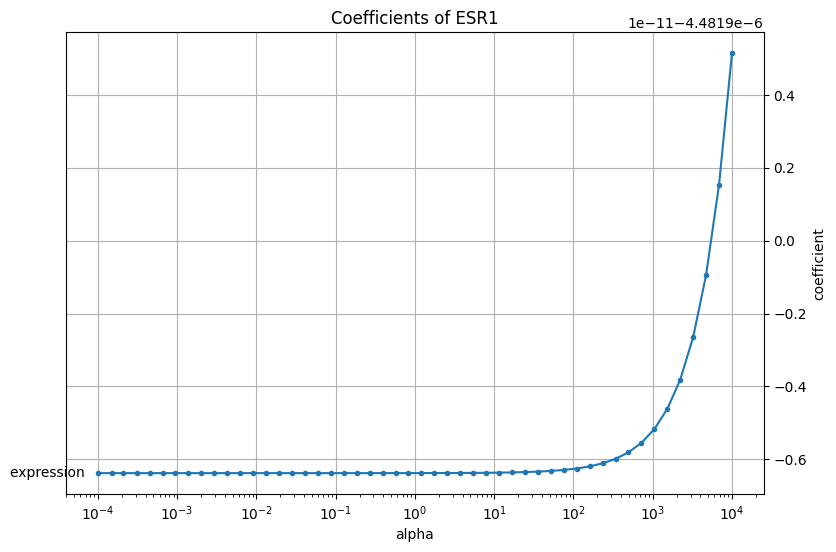

In [61]:
plot_coefficients(betas_ESR1, n_highlight=5, title="Coefficients of ESR1")

In [62]:
"""cox_lasso.fit(X_train_ESR1, X_test_ESR1)
coefficient_lasso = pd.DataFrame(cox_lasso.coef_, index=X.columns, columns=(cox_lasso.alphas_))
plot_coefficients(coefficient_lasso, n_highlight=5, title="ESR1 Coefficients")
cox_lasso.predict(X_test)
"""

'cox_lasso.fit(X_train_ESR1, X_test_ESR1)\ncoefficient_lasso = pd.DataFrame(cox_lasso.coef_, index=X.columns, columns=(cox_lasso.alphas_))\nplot_coefficients(coefficient_lasso, n_highlight=5, title="ESR1 Coefficients")\ncox_lasso.predict(X_test)\n'

In [63]:
df_life_line_ESR1 = df_ESR1_merged[["expression", "event", "Overall Survival (Months)"]]

In [64]:
p_values_Cox_regression(df_life_line_ESR1,event_col="event", duration_col="Overall Survival (Months)")

#p_values = p
#p < 0.05 → hay evidencia de que la variable sí afecta la supervivencia
#p ≥ 0.05 → no hay evidencia suficiente
# p == 0.79 = No significativo

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
expression,-0.000004,0.999996,0.000015,-0.000033,0.000025,0.999967,1.000025,0.0,-0.257217,0.797011,0.327328


<font size="4">AURKA coefficients and p_values</font>

In [65]:
df_AURKA = pp.gene_to_long(clean_df, "AURKA")

In [66]:
df_AURKA_merged = df_AURKA.merge(df_clinical_keep, on="Sample ID", how="inner")
status = df_AURKA_merged["Overall Survival Status"].astype(str).str.strip()
df_AURKA_merged["event"] = status.str.contains("DECEASED", na=False) 
df_AURKA_merged = df_AURKA_merged.dropna(subset=["Overall Survival (Months)"])
X_AURKA = df_AURKA_merged[["expression"]]
Y_surv_AURKA = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=df_AURKA_merged
)

In [67]:
X_train_AURKA, X_test_AURKA, Y_train_AURKA, Y_test_AURKA = train_test_split(
    X_AURKA, Y_surv_AURKA, train_size=0.80, test_size=0.20, random_state=42
)


In [68]:
betas_AURKA, chp_predict_AURKA, survival_curve_AURKA, risk_curve_AURKA = Cox_regression(X_train_AURKA, Y_train_AURKA, X_test_AURKA)

In [23]:
print(betas_AURKA)
#Alpha is regularization 
#Low alpha == Low regularization
#Big alpha == Big regularization

#Espression == Betas 
#β > 0 → aumenta el riesgo
#β < 0 → reduce el riesgo
#β ≈ 0 → no hay efecto

alpha       0.00010      0.00015      0.00021      0.00031      0.00045      \
expression    -0.000002    -0.000002    -0.000002    -0.000002    -0.000002   

alpha       0.00066      0.00095      0.00139      0.00202      0.00295      \
expression    -0.000002    -0.000002    -0.000002    -0.000002    -0.000002   

alpha       ...  339.32218    494.17134    719.68567    1048.11313   \
expression  ...    -0.000002    -0.000002    -0.000002    -0.000002   

alpha       1526.41797   2222.99648   3237.45754   4714.86636   6866.48845   \
expression    -0.000002    -0.000002    -0.000002    -0.000002    -0.000002   

alpha       10000.00000  
expression    -0.000002  

[1 rows x 50 columns]


In [24]:
print(chp_predict_AURKA)

# Risk Score = Expression x β
# valor más alto → mayor riesgo relativo
#valor más bajo → menor riesgo relativo

[-0.00045987 -0.0004478  -0.00019214 -0.00607356 -0.00084914 -0.00040606
 -0.00073634 -0.00205469 -0.00098431 -0.00238117 -0.00026114 -0.00180553
 -0.00394049 -0.00213995 -0.00066283 -0.00053252 -0.00019059 -0.00076849
 -0.00075041 -0.00027709 -0.0012484  -0.00022339 -0.00096148 -0.00077469
 -0.00082735 -0.01061253 -0.00158266 -0.00035362 -0.00029002 -0.00075467
 -0.00056744 -0.00042991 -0.00034457 -0.00030638 -0.00033971 -0.00047915
 -0.00153606 -0.00072167 -0.0002831  -0.00119987 -0.00162013 -0.00034287
 -0.00021992 -0.0003489  -0.00100304 -0.00121767 -0.00051698 -0.00021624
 -0.00212328 -0.00028243 -0.0009641  -0.00115347 -0.00042838 -0.00044249
 -0.00030309 -0.00020911 -0.00144787 -0.00160348 -0.00247449 -0.00042643
 -0.00018601 -0.00070478 -0.00109137 -0.00093831 -0.00049647 -0.00167278
 -0.00063754 -0.00322842 -0.00106687 -0.00073187 -0.00151405 -0.00147096
 -0.00078492 -0.00075083 -0.00100438 -0.00044379 -0.00027774 -0.00042804
 -0.00251505 -0.00287978 -0.00436221 -0.00310464 -0

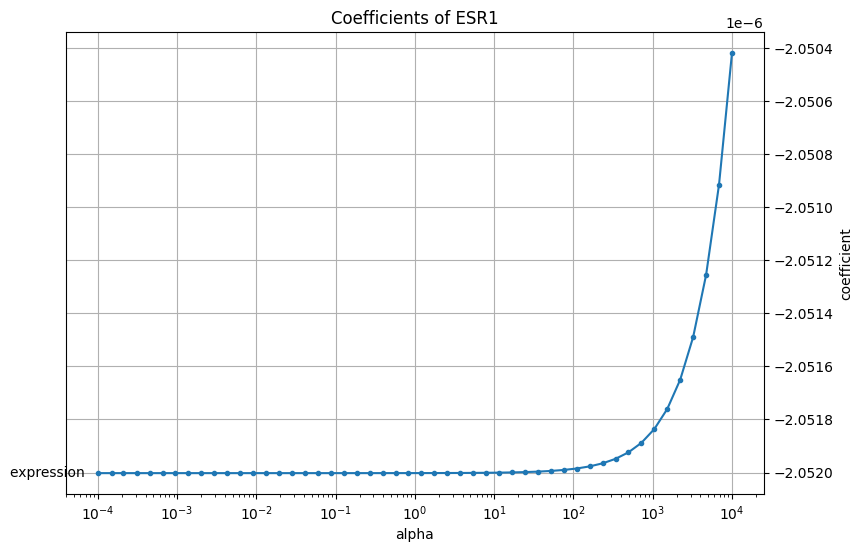

In [25]:
plot_coefficients(betas_AURKA, n_highlight=5, title="Coefficients of ESR1")

In [28]:
df_life_line_AURKA = df_AURKA_merged[["expression", "event", "Overall Survival (Months)"]]

In [29]:
p_values_Cox_regression(df_life_line_AURKA,event_col="event", duration_col="Overall Survival (Months)")

#p_values = p
#p < 0.05 → hay evidencia de que la variable sí afecta la supervivencia
#p ≥ 0.05 → no hay evidencia suficiente
# p == 0.61 = No significativo

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
expression,0.000123,1.000123,0.000247,-0.000362,0.000607,0.999638,1.000607,0.0,0.495879,0.61998,0.689706
